In [ ]:
import zipfile
import os
import json
import glob

# ZIP file uploaded to Colab
zip_path = "/content/t20s_male_json.zip"

# Extract dataset
extract_path = "/content/t20s_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

# Find JSON files
json_files = glob.glob(extract_path + "/**/*.json", recursive=True)

print("Total JSON match files:", len(json_files))

# Display first few files
print("\nFirst 5 JSON files:")
for file in json_files[:5]:
    print(os.path.basename(file))

# Load one match
with open(json_files[0], "r", encoding="utf-8") as f:
    match = json.load(f)

print("\nFirst match loaded successfully!")
print("Top-level keys:")
print(match.keys())

Dataset extracted successfully!
Total JSON match files: 3539

First 5 JSON files:
1443776.json
1485347.json
1459379.json
1512002.json
1001353.json

First match loaded successfully!
Top-level keys:
dict_keys(['meta', 'info', 'innings'])


In [ ]:
# Load and inspect the structure of one T20I match

with open(json_files[0], "r", encoding="utf-8") as f:
    match = json.load(f)

info = match["info"]

print("Teams:", info["teams"])
print("Date:", info["dates"])
print("Venue:", info.get("venue"))
print("Match type:", info.get("match_type"))
print("Outcome:", info.get("outcome"))

Teams: ['Greece', 'Cyprus']
Date: ['2024-08-24']
Venue: King George V Sports Ground, Castel
Match type: T20
Outcome: {'winner': 'Cyprus', 'by': {'wickets': 8}}


In [ ]:
import pandas as pd

matches = []

for file in json_files:
    try:
        with open(file, "r", encoding="utf-8") as f:
            data = json.load(f)

        info = data["info"]
        teams = info.get("teams", [])
        outcome = info.get("outcome", {})

        # Only matches with exactly 2 teams and a winner
        if len(teams) != 2:
            continue

        if "winner" not in outcome:
            continue

        winner = outcome["winner"]

        if winner not in teams:
            continue

        matches.append({
            "match_id": os.path.splitext(os.path.basename(file))[0],
            "date": str(info.get("dates", [""])[0]),
            "season": info.get("season"),
            "venue": info.get("venue", "Unknown"),
            "city": info.get("city", "Unknown"),
            "team_1": teams[0],
            "team_2": teams[1],
            "winner": winner,
            "match_type": info.get("match_type"),
            "gender": info.get("gender"),
            "event": info.get("event", {}).get("name", "Unknown"),
            "toss_winner": info.get("toss", {}).get("winner", "Unknown"),
            "toss_decision": info.get("toss", {}).get("decision", "Unknown")
        })

    except Exception as e:
        # Skip corrupted/unreadable files
        continue

# Create dataframe
t20_matches = pd.DataFrame(matches)

# Convert date and sort chronologically
t20_matches["date"] = pd.to_datetime(
    t20_matches["date"],
    errors="coerce"
)

t20_matches = t20_matches.sort_values(
    "date"
).reset_index(drop=True)

print("T20 match-level dataset created successfully!")
print("Matches with a recorded winner:", len(t20_matches))

T20 match-level dataset created successfully!
Matches with a recorded winner: 3424


In [ ]:
# Extract team performance from ball-by-ball data

team_performance = []

for file in json_files:
    try:
        with open(file, "r", encoding="utf-8") as f:
            data = json.load(f)

        info = data["info"]
        teams = info.get("teams", [])
        outcome = info.get("outcome", {})

        if len(teams) != 2 or "winner" not in outcome:
            continue

        match_id = os.path.splitext(os.path.basename(file))[0]

        # Store performance for each innings/team
        innings_stats = {}

        for innings in data.get("innings", []):

            # Current Cricsheet JSON structure
            team = innings.get("team")

            if not team:
                continue

            total_runs = 0
            wickets = 0
            legal_balls = 0

            for over in innings.get("overs", []):

                for delivery in over.get("deliveries", []):

                    runs = delivery.get("runs", {})

                    # Runs scored by batting team
                    total_runs += runs.get("total", 0)

                    # Count wickets
                    if delivery.get("wickets"):
                        wickets += len(delivery["wickets"])

                    # A delivery is legal unless it contains a wide or no-ball
                    extras = delivery.get("extras", {})

                    if "wides" not in extras and "noballs" not in extras:
                        legal_balls += 1

            # Convert legal balls to overs
            overs_faced = legal_balls / 6

            # Calculate run rate
            run_rate = (
                total_runs / overs_faced
                if overs_faced > 0
                else 0
            )

            innings_stats[team] = {
                "runs": total_runs,
                "wickets": wickets,
                "overs": overs_faced,
                "run_rate": run_rate
            }

        # Only keep matches where both teams have batting data
        if len(innings_stats) >= 2:

            team1 = teams[0]
            team2 = teams[1]

            if team1 in innings_stats and team2 in innings_stats:

                team_performance.append({
                    "match_id": match_id,

                    "team_1_runs": innings_stats[team1]["runs"],
                    "team_1_wickets": innings_stats[team1]["wickets"],
                    "team_1_overs": innings_stats[team1]["overs"],
                    "team_1_run_rate": innings_stats[team1]["run_rate"],

                    "team_2_runs": innings_stats[team2]["runs"],
                    "team_2_wickets": innings_stats[team2]["wickets"],
                    "team_2_overs": innings_stats[team2]["overs"],
                    "team_2_run_rate": innings_stats[team2]["run_rate"]
                })

    except Exception:
        continue

# Convert to dataframe
performance_df = pd.DataFrame(team_performance)

# Merge with match-level information
t20_matches = t20_matches.merge(
    performance_df,
    on="match_id",
    how="inner"
)

print("Performance features added successfully!")
print("Final matches:", len(t20_matches))

Performance features added successfully!
Final matches: 3423


In [ ]:
# Create target variable
# 1 = Team 1 won
# 0 = Team 2 won

t20_matches["target"] = (
    t20_matches["winner"] == t20_matches["team_1"]
).astype(int)

print("Target variable created!")
print(t20_matches["target"].value_counts())

Target variable created!
target
0    1746
1    1677
Name: count, dtype: int64


In [ ]:
# Historical statistics for every team

team_history = {}

historical_features = []

for _, row in t20_matches.iterrows():

    team1 = row["team_1"]
    team2 = row["team_2"]

    # Initialize teams
    for team in [team1, team2]:
        if team not in team_history:
            team_history[team] = {
                "matches": 0,
                "wins": 0,
                "runs": [],
                "wickets": [],
                "run_rates": [],
                "results": []
            }

    # Get historical information BEFORE current match
    def get_history(team):
        h = team_history[team]

        matches = h["matches"]

        win_rate = h["wins"] / matches if matches > 0 else 0
        avg_runs = sum(h["runs"]) / len(h["runs"]) if h["runs"] else 0
        avg_wickets = sum(h["wickets"]) / len(h["wickets"]) if h["wickets"] else 0
        avg_run_rate = sum(h["run_rates"]) / len(h["run_rates"]) if h["run_rates"] else 0

        return {
            "win_rate": win_rate,
            "avg_runs": avg_runs,
            "avg_wickets": avg_wickets,
            "avg_run_rate": avg_run_rate
        }

    h1 = get_history(team1)
    h2 = get_history(team2)

    historical_features.append({
        "match_id": row["match_id"],

        "team_1_win_rate": h1["win_rate"],
        "team_2_win_rate": h2["win_rate"],

        "team_1_avg_runs": h1["avg_runs"],
        "team_2_avg_runs": h2["avg_runs"],

        "team_1_avg_wickets": h1["avg_wickets"],
        "team_2_avg_wickets": h2["avg_wickets"],

        "team_1_avg_run_rate": h1["avg_run_rate"],
        "team_2_avg_run_rate": h2["avg_run_rate"]
    })

    # UPDATE HISTORY AFTER the current match
    winner = row["winner"]

    for team in [team1, team2]:

        team_history[team]["matches"] += 1

        if winner == team:
            team_history[team]["wins"] += 1

        if team == team1:
            team_history[team]["runs"].append(row["team_1_runs"])
            team_history[team]["wickets"].append(row["team_1_wickets"])
            team_history[team]["run_rates"].append(row["team_1_run_rate"])
        else:
            team_history[team]["runs"].append(row["team_2_runs"])
            team_history[team]["wickets"].append(row["team_2_wickets"])
            team_history[team]["run_rates"].append(row["team_2_run_rate"])

# Merge historical statistics
history_df = pd.DataFrame(historical_features)

t20_matches = t20_matches.merge(
    history_df,
    on="match_id",
    how="left"
)

print("Historical statistics added!")

Historical statistics added!


In [ ]:
# Add recent form based on previous 5 matches

recent_history = {}
recent_features = []

for _, row in t20_matches.iterrows():

    team1 = row["team_1"]
    team2 = row["team_2"]

    for team in [team1, team2]:
        if team not in recent_history:
            recent_history[team] = []

    def recent_form(team):
        results = recent_history[team][-5:]

        if not results:
            return 0.5

        return sum(results) / len(results)

    recent_features.append({
        "match_id": row["match_id"],
        "team_1_recent_form": recent_form(team1),
        "team_2_recent_form": recent_form(team2)
    })

    # Update AFTER current match
    winner = row["winner"]

    recent_history[team1].append(
        1 if winner == team1 else 0
    )

    recent_history[team2].append(
        1 if winner == team2 else 0
    )

recent_df = pd.DataFrame(recent_features)

t20_matches = t20_matches.merge(
    recent_df,
    on="match_id",
    how="left"
)

print("Recent form added!")

Recent form added!


In [ ]:
# Head-to-head win rate

h2h_history = {}
h2h_features = []

for _, row in t20_matches.iterrows():

    team1 = row["team_1"]
    team2 = row["team_2"]

    pair = tuple(sorted([team1, team2]))

    if pair not in h2h_history:
        h2h_history[pair] = {
            team1: 0,
            team2: 0,
            "matches": 0
        }

    h = h2h_history[pair]

    previous_matches = h["matches"]

    if previous_matches > 0:
        team1_h2h_win_rate = h[team1] / previous_matches
    else:
        team1_h2h_win_rate = 0.5

    h2h_features.append({
        "match_id": row["match_id"],
        "team_1_h2h_win_rate": team1_h2h_win_rate
    })

    # Update after current match
    winner = row["winner"]

    if winner == team1:
        h[team1] += 1
    elif winner == team2:
        h[team2] += 1

    h["matches"] += 1

h2h_df = pd.DataFrame(h2h_features)

t20_matches = t20_matches.merge(
    h2h_df,
    on="match_id",
    how="left"
)

print("Head-to-head history added!")

Head-to-head history added!


In [ ]:
# Chronological Elo ratings

elo = {}
elo_features = []

INITIAL_ELO = 1500
K = 20

for _, row in t20_matches.iterrows():

    team1 = row["team_1"]
    team2 = row["team_2"]

    elo.setdefault(team1, INITIAL_ELO)
    elo.setdefault(team2, INITIAL_ELO)

    rating1 = elo[team1]
    rating2 = elo[team2]

    elo_features.append({
        "match_id": row["match_id"],
        "team_1_elo": rating1,
        "team_2_elo": rating2,
        "elo_diff": rating1 - rating2
    })

    # Expected probability
    expected1 = 1 / (
        1 + 10 ** ((rating2 - rating1) / 400)
    )

    actual1 = 1 if row["winner"] == team1 else 0

    # Update ratings AFTER current match
    elo[team1] = rating1 + K * (actual1 - expected1)
    elo[team2] = rating2 + K * ((1 - actual1) - (1 - expected1))

elo_df = pd.DataFrame(elo_features)

t20_matches = t20_matches.merge(
    elo_df,
    on="match_id",
    how="left"
)

print("Elo ratings added!")

Elo ratings added!


In [ ]:
# Create difference-based model features

t20_matches["win_rate_diff"] = (
    t20_matches["team_1_win_rate"] -
    t20_matches["team_2_win_rate"]
)

t20_matches["recent_form_diff"] = (
    t20_matches["team_1_recent_form"] -
    t20_matches["team_2_recent_form"]
)

t20_matches["avg_runs_diff"] = (
    t20_matches["team_1_avg_runs"] -
    t20_matches["team_2_avg_runs"]
)

t20_matches["avg_wickets_diff"] = (
    t20_matches["team_1_avg_wickets"] -
    t20_matches["team_2_avg_wickets"]
)

t20_matches["run_rate_diff"] = (
    t20_matches["team_1_avg_run_rate"] -
    t20_matches["team_2_avg_run_rate"]
)

# Final feature list
t20_features = [
    "elo_diff",
    "win_rate_diff",
    "recent_form_diff",
    "avg_runs_diff",
    "avg_wickets_diff",
    "run_rate_diff",
    "team_1_h2h_win_rate"
]

print("Final T20 feature set created!")
print(t20_features)

Final T20 feature set created!
['elo_diff', 'win_rate_diff', 'recent_form_diff', 'avg_runs_diff', 'avg_wickets_diff', 'run_rate_diff', 'team_1_h2h_win_rate']


In [ ]:
# Prepare data for machine learning

model_data = t20_matches.copy()

# Keep only rows with all required features
model_data = model_data.dropna(
    subset=t20_features + ["target", "date"]
).reset_index(drop=True)

# Replace infinite values if any
model_data = model_data.replace(
    [float("inf"), float("-inf")],
    pd.NA
).dropna(
    subset=t20_features + ["target"]
).reset_index(drop=True)

print("Clean modeling dataset ready!")
print("Total matches:", len(model_data))

Clean modeling dataset ready!
Total matches: 3423


In [ ]:
# Chronological split

n = len(model_data)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_data = model_data.iloc[:train_end]
val_data = model_data.iloc[train_end:val_end]
test_data = model_data.iloc[val_end:]

X_train = train_data[t20_features]
y_train = train_data["target"]

X_val = val_data[t20_features]
y_val = val_data["target"]

X_test = test_data[t20_features]
y_test = test_data["target"]

print("Training matches:", len(train_data))
print("Validation matches:", len(val_data))
print("Testing matches:", len(test_data))

Training matches: 2396
Validation matches: 513
Testing matches: 514


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Logistic Regression pipeline
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train
lr_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Predictions
lr_prob = lr_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]

lr_pred = (lr_prob >= 0.50).astype(int)
rf_pred = (rf_prob >= 0.50).astype(int)

# Metrics
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print("===== LOGISTIC REGRESSION =====")
print("Accuracy:", round(lr_accuracy, 4))
print("F1 Score:", round(lr_f1, 4))
print("ROC-AUC:", round(lr_auc, 4))

print("\n===== RANDOM FOREST =====")
print("Accuracy:", round(rf_accuracy, 4))
print("F1 Score:", round(rf_f1, 4))
print("ROC-AUC:", round(rf_auc, 4))

===== LOGISTIC REGRESSION =====
Accuracy: 0.7101
F1 Score: 0.7061
ROC-AUC: 0.7856

===== RANDOM FOREST =====
Accuracy: 0.7004
F1 Score: 0.6969
ROC-AUC: 0.7867


In [ ]:
import numpy as np

# Validation probabilities
lr_val_prob = lr_model.predict_proba(X_val)[:, 1]

threshold_results = []

for threshold in np.arange(0.40, 0.71, 0.01):

    val_pred = (
        lr_val_prob >= threshold
    ).astype(int)

    accuracy = accuracy_score(
        y_val,
        val_pred
    )

    threshold_results.append({
        "threshold": round(threshold, 2),
        "accuracy": accuracy
    })

threshold_df = pd.DataFrame(threshold_results)

best_row = threshold_df.loc[
    threshold_df["accuracy"].idxmax()
]

best_threshold = float(best_row["threshold"])

print("Best validation threshold:", best_threshold)
print(
    "Validation accuracy:",
    round(best_row["accuracy"], 4)
)


Best validation threshold: 0.49
Validation accuracy: 0.7368


In [ ]:
print("Selected Logistic Regression threshold:", best_threshold)

Selected Logistic Regression threshold: 0.49


In [ ]:
# Final Logistic Regression predictions
# Threshold was selected using validation data

lr_test_pred = (
    lr_prob >= best_threshold
).astype(int)

final_lr_accuracy = accuracy_score(
    y_test,
    lr_test_pred
)

final_lr_f1 = f1_score(
    y_test,
    lr_test_pred
)

print("===== FINAL LOGISTIC REGRESSION =====")
print("Threshold:", best_threshold)
print("Accuracy:", round(final_lr_accuracy, 4))
print("F1 Score:", round(final_lr_f1, 4))
print("ROC-AUC:", round(lr_auc, 4))

===== FINAL LOGISTIC REGRESSION =====
Threshold: 0.49
Accuracy: 0.7023
F1 Score: 0.7041
ROC-AUC: 0.7856


In [ ]:
print("===== LOGISTIC REGRESSION CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        lr_test_pred,
        target_names=[
            "Team 2 Win",
            "Team 1 Win"
        ]
    )
)

===== LOGISTIC REGRESSION CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

  Team 2 Win       0.69      0.71      0.70       251
  Team 1 Win       0.72      0.69      0.70       263

    accuracy                           0.70       514
   macro avg       0.70      0.70      0.70       514
weighted avg       0.70      0.70      0.70       514



Confusion Matrix:
[[179  72]
 [ 81 182]]


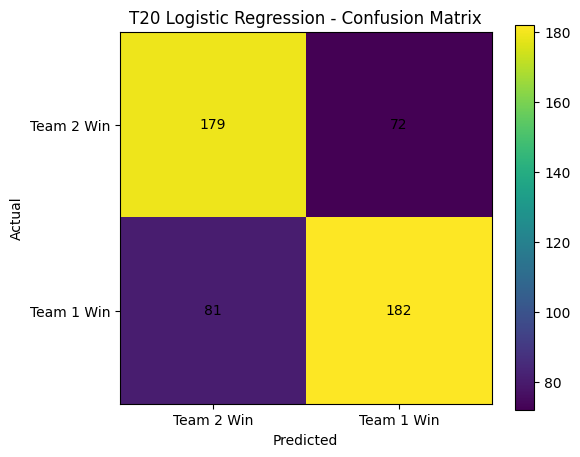

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    lr_test_pred
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("T20 Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Team 2 Win", "Team 1 Win"]
)

plt.yticks(
    [0, 1],
    ["Team 2 Win", "Team 1 Win"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        final_lr_accuracy,
        rf_accuracy
    ],
    "F1 Score": [
        final_lr_f1,
        rf_f1
    ],
    "ROC-AUC": [
        lr_auc,
        rf_auc
    ]
})

comparison

,Model,Accuracy,F1 Score,ROC-AUC
0,Logistic Regression,0.702335,0.704062,0.785557
1,Random Forest,0.700389,0.696850,0.786739


In [ ]:
import joblib

joblib.dump(
    lr_model,
    "t20_match_outcome_model.pkl"
)

joblib.dump(
    best_threshold,
    "t20_prediction_threshold.pkl"
)

joblib.dump(
    t20_features,
    "t20_model_features.pkl"
)

t20_matches.to_csv(
    "t20_match_data_for_prediction.csv",
    index=False
)

print("T20 model files saved successfully!")

print("\nFiles:")
print("1. t20_match_outcome_model.pkl")
print("2. t20_prediction_threshold.pkl")
print("3. t20_model_features.pkl")
print("4. t20_match_data_for_prediction.csv")

T20 model files saved successfully!

Files:
1. t20_match_outcome_model.pkl
2. t20_prediction_threshold.pkl
3. t20_model_features.pkl
4. t20_match_data_for_prediction.csv


In [ ]:
# List all teams available in the T20 dataset

t20_teams = sorted(
    set(t20_matches["team_1"].dropna()) |
    set(t20_matches["team_2"].dropna())
)

print("Total teams:", len(t20_teams))
print("\nTeams:")
for team in t20_teams:
    print("-", team)

Total teams: 109

Teams:
- Argentina
- Australia
- Austria
- Bahamas
- Bahrain
- Bangladesh
- Belgium
- Belize
- Bermuda
- Bhutan
- Botswana
- Brazil
- Bulgaria
- Cambodia
- Cameroon
- Canada
- Cayman Islands
- Chile
- China
- Cook Islands
- Costa Rica
- Croatia
- Cyprus
- Czech Republic
- Denmark
- England
- Estonia
- Eswatini
- Fiji
- Finland
- France
- Gambia
- Germany
- Ghana
- Gibraltar
- Greece
- Guernsey
- Hong Kong
- Hungary
- ICC World XI
- India
- Indonesia
- Iran
- Ireland
- Isle of Man
- Israel
- Italy
- Ivory Coast
- Japan
- Jersey
- Kenya
- Kuwait
- Lesotho
- Luxembourg
- Malawi
- Malaysia
- Maldives
- Mali
- Malta
- Mexico
- Mongolia
- Mozambique
- Myanmar
- Namibia
- Nepal
- Netherlands
- New Zealand
- Nigeria
- Norway
- Oman
- Pakistan
- Panama
- Papua New Guinea
- Peru
- Philippines
- Portugal
- Qatar
- Romania
- Rwanda
- Samoa
- Saudi Arabia
- Scotland
- Serbia
- Seychelles
- Sierra Leone
- Singapore
- Slovenia
- South Africa
- South Korea
- Spain
- Sri Lanka
- St He

In [ ]:
# Build latest historical statistics for each team

current_stats = {}

for _, row in t20_matches.sort_values("date").iterrows():

    for team in [row["team_1"], row["team_2"]]:

        if team not in current_stats:
            current_stats[team] = {
                "matches": 0,
                "wins": 0,
                "runs": [],
                "wickets": [],
                "run_rates": [],
                "results": []
            }

    team1 = row["team_1"]
    team2 = row["team_2"]

    # Team 1
    current_stats[team1]["matches"] += 1
    current_stats[team1]["wins"] += int(row["winner"] == team1)
    current_stats[team1]["runs"].append(row["team_1_runs"])
    current_stats[team1]["wickets"].append(row["team_1_wickets"])
    current_stats[team1]["run_rates"].append(row["team_1_run_rate"])
    current_stats[team1]["results"].append(
        1 if row["winner"] == team1 else 0
    )

    # Team 2
    current_stats[team2]["matches"] += 1
    current_stats[team2]["wins"] += int(row["winner"] == team2)
    current_stats[team2]["runs"].append(row["team_2_runs"])
    current_stats[team2]["wickets"].append(row["team_2_wickets"])
    current_stats[team2]["run_rates"].append(row["team_2_run_rate"])
    current_stats[team2]["results"].append(
        1 if row["winner"] == team2 else 0
    )

print("Current team statistics created!")
print("Teams tracked:", len(current_stats))

Current team statistics created!
Teams tracked: 109


In [ ]:
# Calculate latest Elo rating for every team

final_elo = {}

INITIAL_ELO = 1500
K = 20

for _, row in t20_matches.sort_values("date").iterrows():

    team1 = row["team_1"]
    team2 = row["team_2"]

    final_elo.setdefault(team1, INITIAL_ELO)
    final_elo.setdefault(team2, INITIAL_ELO)

    rating1 = final_elo[team1]
    rating2 = final_elo[team2]

    expected1 = 1 / (
        1 + 10 ** ((rating2 - rating1) / 400)
    )

    actual1 = 1 if row["winner"] == team1 else 0

    final_elo[team1] = rating1 + K * (
        actual1 - expected1
    )

    final_elo[team2] = rating2 + K * (
        (1 - actual1) - (1 - expected1)
    )

print("Final Elo ratings calculated!")

Final Elo ratings calculated!


In [ ]:
# Build latest head-to-head statistics

h2h_stats = {}

for _, row in t20_matches.sort_values("date").iterrows():

    team1 = row["team_1"]
    team2 = row["team_2"]

    pair = tuple(sorted([team1, team2]))

    if pair not in h2h_stats:
        h2h_stats[pair] = {
            "matches": 0,
            team1: 0,
            team2: 0
        }

    h = h2h_stats[pair]

    winner = row["winner"]

    if winner == team1:
        h[team1] += 1

    elif winner == team2:
        h[team2] += 1

    h["matches"] += 1

print("Head-to-head statistics created!")
print("H2H pairs:", len(h2h_stats))

Head-to-head statistics created!
H2H pairs: 868


In [ ]:
def predict_t20_match(team1, team2):

    if team1 not in current_stats:
        raise ValueError(f"Team not found: {team1}")

    if team2 not in current_stats:
        raise ValueError(f"Team not found: {team2}")

    s1 = current_stats[team1]
    s2 = current_stats[team2]

    # Win rate
    win_rate_1 = s1["wins"] / s1["matches"]
    win_rate_2 = s2["wins"] / s2["matches"]

    # Recent form - last 5 matches
    recent_1 = s1["results"][-5:]
    recent_2 = s2["results"][-5:]

    form_1 = sum(recent_1) / len(recent_1)
    form_2 = sum(recent_2) / len(recent_2)

    # Average statistics
    avg_runs_1 = sum(s1["runs"]) / len(s1["runs"])
    avg_runs_2 = sum(s2["runs"]) / len(s2["runs"])

    avg_wickets_1 = sum(s1["wickets"]) / len(s1["wickets"])
    avg_wickets_2 = sum(s2["wickets"]) / len(s2["wickets"])

    avg_rr_1 = sum(s1["run_rates"]) / len(s1["run_rates"])
    avg_rr_2 = sum(s2["run_rates"]) / len(s2["run_rates"])

    # Elo
    elo_1 = final_elo.get(team1, INITIAL_ELO)
    elo_2 = final_elo.get(team2, INITIAL_ELO)

    # H2H
    pair = tuple(sorted([team1, team2]))

    if pair in h2h_stats:
        h = h2h_stats[pair]

        if h["matches"] > 0:
            h2h_1 = h.get(team1, 0) / h["matches"]
        else:
            h2h_1 = 0.5
    else:
        h2h_1 = 0.5

    # Model features
    features = pd.DataFrame([{
        "elo_diff": elo_1 - elo_2,
        "win_rate_diff": win_rate_1 - win_rate_2,
        "recent_form_diff": form_1 - form_2,
        "avg_runs_diff": avg_runs_1 - avg_runs_2,
        "avg_wickets_diff": avg_wickets_1 - avg_wickets_2,
        "run_rate_diff": avg_rr_1 - avg_rr_2,
        "team_1_h2h_win_rate": h2h_1
    }])[t20_features]

    # Probability
    probability = lr_model.predict_proba(features)[0][1]

    # Apply selected threshold
    prediction = (
        team1 if probability >= best_threshold
        else team2
    )

    return {
        "team_1": team1,
        "team_2": team2,
        "team_1_probability": probability,
        "team_2_probability": 1 - probability,
        "prediction": prediction,
        "threshold": best_threshold,
        "features": features.iloc[0].to_dict()
    }

In [ ]:
# Test the T20 prediction engine

team1 = t20_teams[0]
team2 = t20_teams[1]

result = predict_t20_match(team1, team2)

print("===== MATCHAI T20 PREDICTION =====")
print("Team 1:", result["team_1"])
print("Team 2:", result["team_2"])

print(
    f"\n{result['team_1']} probability: "
    f"{result['team_1_probability']:.2%}"
)

print(
    f"{result['team_2']} probability: "
    f"{result['team_2_probability']:.2%}"
)

print("\nPredicted winner:", result["prediction"])
print("Decision threshold:", result["threshold"])

print("\nModel features:")
for key, value in result["features"].items():
    print(f"{key}: {value:.4f}")

===== MATCHAI T20 PREDICTION =====
Team 1: Argentina
Team 2: Australia

Argentina probability: 19.75%
Australia probability: 80.25%

Predicted winner: Australia
Decision threshold: 0.49

Model features:
elo_diff: -174.1513
win_rate_diff: -0.0289
recent_form_diff: 0.0000
avg_runs_diff: -40.9735
avg_wickets_diff: 0.3450
run_rate_diff: -2.1977
team_1_h2h_win_rate: 0.5000


In [ ]:
# Final evaluation on the untouched test set

final_lr_prob = lr_model.predict_proba(X_test)[:, 1]

final_lr_pred = (
    final_lr_prob >= best_threshold
).astype(int)

final_accuracy = accuracy_score(
    y_test,
    final_lr_pred
)

final_f1 = f1_score(
    y_test,
    final_lr_pred
)

final_auc = roc_auc_score(
    y_test,
    final_lr_prob
)

print("===== FINAL T20 MODEL =====")
print("Model: Logistic Regression")
print("Threshold:", best_threshold)
print("Accuracy:", round(final_accuracy, 4))
print("F1 Score:", round(final_f1, 4))
print("ROC-AUC:", round(final_auc, 4))

===== FINAL T20 MODEL =====
Model: Logistic Regression
Threshold: 0.49
Accuracy: 0.7023
F1 Score: 0.7041
ROC-AUC: 0.7856


In [ ]:
cm = confusion_matrix(
    y_test,
    final_lr_pred
)

print("===== FINAL CONFUSION MATRIX =====")
print(cm)

print("\nTrue Negatives :", cm[0, 0])
print("False Positives:", cm[0, 1])
print("False Negatives:", cm[1, 0])
print("True Positives :", cm[1, 1])

===== FINAL CONFUSION MATRIX =====
[[179  72]
 [ 81 182]]

True Negatives : 179
False Positives: 72
False Negatives: 81
True Positives : 182


In [ ]:
# Feature coefficients

coefficients = lr_model.named_steps["model"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": t20_features,
    "Coefficient": coefficients,
    "Absolute_Impact": abs(coefficients)
})

feature_importance = feature_importance.sort_values(
    "Absolute_Impact",
    ascending=False
).reset_index(drop=True)

print("===== T20 FEATURE IMPACT =====")
print(feature_importance)

===== T20 FEATURE IMPACT =====
               Feature  Coefficient  Absolute_Impact
0        run_rate_diff     0.354751         0.354751
1     avg_wickets_diff    -0.284105         0.284105
2        win_rate_diff    -0.248574         0.248574
3        avg_runs_diff     0.241659         0.241659
4             elo_diff     0.235376         0.235376
5  team_1_h2h_win_rate     0.218949         0.218949
6     recent_form_diff     0.189944         0.189944


In [ ]:
import joblib

# Save final model
joblib.dump(
    lr_model,
    "t20_match_outcome_model.pkl"
)

# Save threshold
joblib.dump(
    best_threshold,
    "t20_prediction_threshold.pkl"
)

# Save feature list
joblib.dump(
    t20_features,
    "t20_model_features.pkl"
)

# Save prediction data
t20_matches.to_csv(
    "t20_match_data_for_prediction.csv",
    index=False
)

# Save feature coefficients
feature_importance.to_csv(
    "t20_feature_coefficients.csv",
    index=False
)

print("All T20 model files saved successfully!")

All T20 model files saved successfully!


In [ ]:
import json

model_info = {
    "model_name": "MATCHAI T20 Match Outcome Predictor",
    "algorithm": "Logistic Regression",
    "dataset": "Men's T20 Internationals",
    "features": t20_features,
    "threshold": best_threshold,
    "accuracy": float(final_accuracy),
    "f1_score": float(final_f1),
    "roc_auc": float(final_auc),
    "initial_elo": 1500,
    "elo_k_factor": 20,
    "recent_form_matches": 5
}

with open(
    "t20_model_info.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        model_info,
        f,
        indent=4
    )

print("Model information saved!")

Model information saved!


In [ ]:
import zipfile
import os

t20_files = [
    "t20_match_outcome_model.pkl",
    "t20_prediction_threshold.pkl",
    "t20_model_features.pkl",
    "t20_match_data_for_prediction.csv",
    "t20_feature_coefficients.csv",
    "t20_model_info.json"
]

with zipfile.ZipFile(
    "MATCHAI_T20_Model.zip",
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for file in t20_files:
        if os.path.exists(file):
            zipf.write(file)

print("MATCHAI_T20_Model.zip created successfully!")

MATCHAI_T20_Model.zip created successfully!


In [ ]:
from google.colab import files

files.download("MATCHAI_T20_Model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================================
# T20 FEATURE EXPERIMENT — CELL 1
# CHECK DATA
# ==========================================

print("T20 dataset shape:", t20_matches.shape)

print("\nRequired columns:")

required = [
    "team_1",
    "team_2",
    "venue",
    "toss_winner",
    "toss_decision",
    "target"
]

for col in required:
    if col in t20_matches.columns:
        print("✓", col)
    else:
        print("✗", col)

T20 dataset shape: (3423, 41)

Required columns:
✓ team_1
✓ team_2
✓ venue
✓ toss_winner
✓ toss_decision
✓ target


In [ ]:
# ==========================================
# T20 FEATURE EXPERIMENT — CELL 2
# VENUE PERFORMANCE
# ==========================================

from collections import defaultdict

t20_venue_history = defaultdict(
    lambda: {
        "matches": 0,
        "wins": 0
    }
)

t20_venue_rates = []

t20_sorted = t20_matches.sort_values(
    "date"
).copy()

for _, row in t20_sorted.iterrows():

    team1 = row["team_1"]
    team2 = row["team_2"]
    venue = row["venue"]

    stats1 = t20_venue_history[
        (team1, venue)
    ]

    stats2 = t20_venue_history[
        (team2, venue)
    ]

    rate1 = (
        stats1["wins"] / stats1["matches"]
        if stats1["matches"] > 0
        else 0.5
    )

    rate2 = (
        stats2["wins"] / stats2["matches"]
        if stats2["matches"] > 0
        else 0.5
    )

    t20_venue_rates.append(
        rate1 - rate2
    )

    # Update only AFTER feature calculation
    stats1["matches"] += 1
    stats2["matches"] += 1

    if row["target"] == 1:
        stats1["wins"] += 1
    else:
        stats2["wins"] += 1

t20_sorted["venue_win_rate_diff"] = (
    t20_venue_rates
)

t20_matches = t20_sorted.reset_index(
    drop=True
)

print("✓ Venue feature created")

display(
    t20_matches[
        [
            "team_1",
            "team_2",
            "venue",
            "venue_win_rate_diff",
            "target"
        ]
    ].head()
)

✓ Venue feature created


,team_1,team_2,venue,venue_win_rate_diff,target
0,New Zealand,Australia,Eden Park,0.0,0
1,England,Australia,The Rose Bowl,0.0,1
2,South Africa,New Zealand,New Wanderers Stadium,0.0,0
3,Australia,South Africa,"Brisbane Cricket Ground, Woolloongabba",0.0,1
4,South Africa,Australia,New Wanderers Stadium,-0.5,1


In [ ]:
# ==========================================
# T20 FEATURE EXPERIMENT — CELL 3
# TOSS FEATURES
# ==========================================

def calculate_t20_toss_features(row):

    team1 = row["team_1"]
    team2 = row["team_2"]

    toss_winner = row["toss_winner"]
    decision = str(
        row["toss_decision"]
    ).lower()

    # Toss winner from Team 1 perspective
    if toss_winner == team1:
        toss_diff = 1

    elif toss_winner == team2:
        toss_diff = -1

    else:
        toss_diff = 0

    # Bat-first from Team 1 perspective
    if toss_winner == team1:

        if decision == "bat":
            bat_first_diff = 1
        else:
            bat_first_diff = -1

    elif toss_winner == team2:

        if decision == "bat":
            bat_first_diff = -1
        else:
            bat_first_diff = 1

    else:
        bat_first_diff = 0

    return toss_diff, bat_first_diff


t20_toss_values = t20_matches.apply(
    calculate_t20_toss_features,
    axis=1
)

t20_matches["toss_winner_diff"] = [
    x[0] for x in t20_toss_values
]

t20_matches["bat_first_diff"] = [
    x[1] for x in t20_toss_values
]

print("✓ Toss features created")

display(
    t20_matches[
        [
            "team_1",
            "team_2",
            "toss_winner",
            "toss_decision",
            "toss_winner_diff",
            "bat_first_diff"
        ]
    ].head()
)

✓ Toss features created


,team_1,team_2,toss_winner,toss_decision,toss_winner_diff,bat_first_diff
0,New Zealand,Australia,Australia,bat,-1,-1
1,England,Australia,England,bat,1,1
2,South Africa,New Zealand,New Zealand,field,-1,1
3,Australia,South Africa,Australia,bat,1,1
4,South Africa,Australia,South Africa,bat,1,1


In [ ]:
# ==========================================
# T20 FEATURE EXPERIMENT — CELL 4
# VENUE + TOSS DATASET
# ==========================================

t20_features_venue_toss = t20_features + [
    "venue_win_rate_diff",
    "toss_winner_diff",
    "bat_first_diff"
]

X_t20_vt = t20_matches[
    t20_features_venue_toss
].copy()

y_t20_vt = t20_matches[
    "target"
].copy()

n = len(t20_matches)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_t20_vt_train = X_t20_vt.iloc[
    :train_end
].copy()

X_t20_vt_test = X_t20_vt.iloc[
    val_end:
].copy()

y_t20_vt_train = y_t20_vt.iloc[
    :train_end
].copy()

y_t20_vt_test = y_t20_vt.iloc[
    val_end:
].copy()

print("=" * 60)
print("T20 + VENUE + TOSS")
print("=" * 60)

print("Features:", len(t20_features_venue_toss))
print("Train:", len(X_t20_vt_train))
print("Test:", len(X_t20_vt_test))

print("\nFeatures:")
for feature in t20_features_venue_toss:
    print("✓", feature)

T20 + VENUE + TOSS
Features: 10
Train: 2396
Test: 514

Features:
✓ elo_diff
✓ win_rate_diff
✓ recent_form_diff
✓ avg_runs_diff
✓ avg_wickets_diff
✓ run_rate_diff
✓ team_1_h2h_win_rate
✓ venue_win_rate_diff
✓ toss_winner_diff
✓ bat_first_diff


In [ ]:
# ==========================================
# T20 FEATURE EXPERIMENT — CELL 5
# LOGISTIC REGRESSION
# ==========================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_t20_vt = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

lr_t20_vt.fit(
    X_t20_vt_train,
    y_t20_vt_train
)

lr_t20_vt_pred = lr_t20_vt.predict(
    X_t20_vt_test
)

lr_t20_vt_proba = (
    lr_t20_vt.predict_proba(
        X_t20_vt_test
    )
)

print(
    "✓ T20 Logistic Regression "
    "+ Venue + Toss trained"
)

✓ T20 Logistic Regression + Venue + Toss trained


In [ ]:
# ==========================================
# T20 FEATURE EXPERIMENT — CELL 6
# RANDOM FOREST
# ==========================================

from sklearn.ensemble import RandomForestClassifier

rf_t20_vt = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_t20_vt.fit(
    X_t20_vt_train,
    y_t20_vt_train
)

rf_t20_vt_pred = rf_t20_vt.predict(
    X_t20_vt_test
)

rf_t20_vt_proba = (
    rf_t20_vt.predict_proba(
        X_t20_vt_test
    )
)

print(
    "✓ T20 Random Forest "
    "+ Venue + Toss trained"
)

✓ T20 Random Forest + Venue + Toss trained


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Logistic Regression metrics
lr_t20_vt_accuracy = accuracy_score(y_t20_vt_test, lr_t20_vt_pred)
lr_t20_vt_f1 = f1_score(y_t20_vt_test, lr_t20_vt_pred)

lr_t20_vt_auc = roc_auc_score(
    y_t20_vt_test,
    lr_t20_vt_proba[:, 1]
)

# Random Forest metrics
rf_t20_vt_accuracy = accuracy_score(y_t20_vt_test, rf_t20_vt_pred)
rf_t20_vt_f1 = f1_score(y_t20_vt_test, rf_t20_vt_pred)

rf_t20_vt_auc = roc_auc_score(
    y_t20_vt_test,
    rf_t20_vt_proba[:, 1]
)

print("T20 + Venue + Toss Results")
print("-" * 40)

print("\nLogistic Regression")
print(f"Accuracy : {lr_t20_vt_accuracy:.4f}")
print(f"F1 Score : {lr_t20_vt_f1:.4f}")
print(f"ROC-AUC  : {lr_t20_vt_auc:.4f}")

print("\nRandom Forest")
print(f"Accuracy : {rf_t20_vt_accuracy:.4f}")
print(f"F1 Score : {rf_t20_vt_f1:.4f}")
print(f"ROC-AUC  : {rf_t20_vt_auc:.4f}")

T20 + Venue + Toss Results
----------------------------------------

Logistic Regression
Accuracy : 0.6868
F1 Score : 0.6824
ROC-AUC  : 0.7889

Random Forest
Accuracy : 0.7082
F1 Score : 0.7170
ROC-AUC  : 0.7927


In [ ]:
print("T20 MODEL COMPARISON")
print("=" * 65)

print(f"{'Model':<30} {'Accuracy':<12} {'F1':<12} {'ROC-AUC':<12}")
print("-" * 65)

print(f"{'LR Baseline':<30} {'71.01%':<12} {'70.61%':<12} {'0.7856':<12}")
print(f"{'RF Baseline':<30} {'70.04%':<12} {'69.69%':<12} {'0.7867':<12}")

print(f"{'LR + Venue + Toss':<30} "
      f"{lr_t20_vt_accuracy*100:.2f}%{'':<7} "
      f"{lr_t20_vt_f1*100:.2f}%{'':<7} "
      f"{lr_t20_vt_auc:.4f}")

print(f"{'RF + Venue + Toss':<30} "
      f"{rf_t20_vt_accuracy*100:.2f}%{'':<7} "
      f"{rf_t20_vt_f1*100:.2f}%{'':<7} "
      f"{rf_t20_vt_auc:.4f}")

T20 MODEL COMPARISON
Model                          Accuracy     F1           ROC-AUC     
-----------------------------------------------------------------
LR Baseline                    71.01%       70.61%       0.7856      
RF Baseline                    70.04%       69.69%       0.7867      
LR + Venue + Toss              68.68%        68.24%        0.7889
RF + Venue + Toss              70.82%        71.70%        0.7927


In [ ]:
import pandas as pd

t20_feature_importance = pd.DataFrame({
    "Feature": t20_features_venue_toss,
    "Importance": rf_t20_vt.feature_importances_
}).sort_values("Importance", ascending=False)

print("T20 Random Forest Feature Importance")
print("=" * 50)
print(t20_feature_importance.to_string(index=False))

T20 Random Forest Feature Importance
            Feature  Importance
      avg_runs_diff    0.184302
      run_rate_diff    0.181584
           elo_diff    0.132078
   avg_wickets_diff    0.130349
      win_rate_diff    0.126607
venue_win_rate_diff    0.079038
team_1_h2h_win_rate    0.077590
   recent_form_diff    0.069783
   toss_winner_diff    0.009916
     bat_first_diff    0.008753


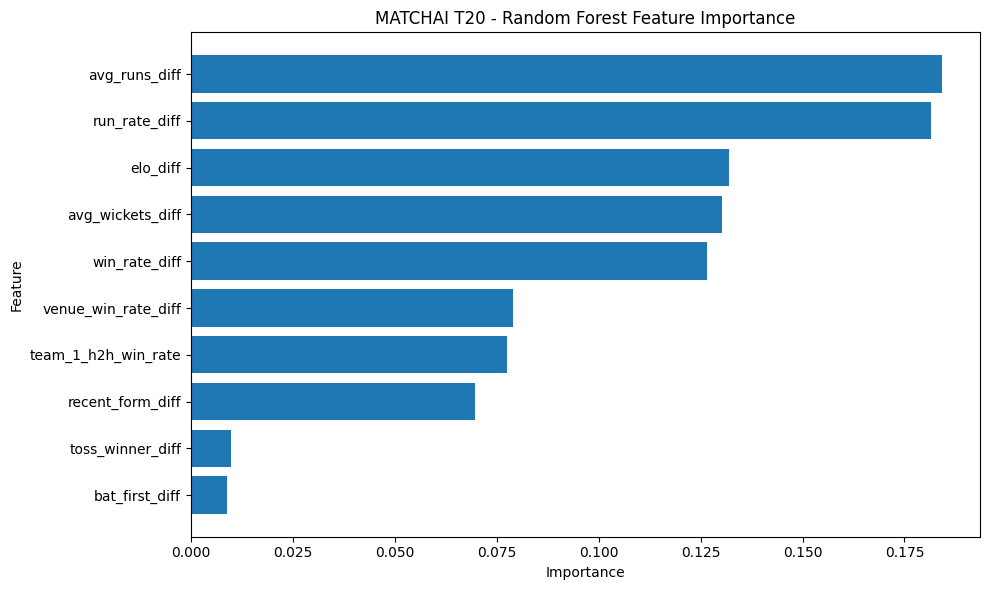

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    t20_feature_importance["Feature"],
    t20_feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("MATCHAI T20 - Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Final T20 feature set
t20_final_features = t20_features + [
    "venue_win_rate_diff",
    "toss_winner_diff",
    "bat_first_diff"
]

X_t20_final = t20_matches[t20_final_features].copy()
y_t20_final = t20_matches["target"].copy()

# Final model trained on all available historical matches
t20_final_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

t20_final_model.fit(X_t20_final, y_t20_final)

print("Final T20 model trained successfully.")
print("Training samples:", len(X_t20_final))
print("Features:", len(t20_final_features))
print("Feature list:")
print(t20_final_features)

Final T20 model trained successfully.
Training samples: 3423
Features: 10
Feature list:
['elo_diff', 'win_rate_diff', 'recent_form_diff', 'avg_runs_diff', 'avg_wickets_diff', 'run_rate_diff', 'team_1_h2h_win_rate', 'venue_win_rate_diff', 'toss_winner_diff', 'bat_first_diff']


In [ ]:
import pickle
import json

with open("t20_final_match_outcome_model.pkl", "wb") as f:
    pickle.dump(t20_final_model, f)

with open("t20_final_model_features.pkl", "wb") as f:
    pickle.dump(t20_final_features, f)

t20_model_info = {
    "model": "Random Forest",
    "format": "T20",
    "features": t20_final_features,
    "n_estimators": 500,
    "max_depth": 8,
    "min_samples_leaf": 4,
    "class_weight": "balanced",
    "historical_matches": len(t20_matches),
    "venue_used": True,
    "toss_used": True,
    "pitch_type_used_for_prediction": False
}

with open("t20_final_model_info.json", "w") as f:
    json.dump(t20_model_info, f, indent=4)

print("Saved:")
print("✓ t20_final_match_outcome_model.pkl")
print("✓ t20_final_model_features.pkl")
print("✓ t20_final_model_info.json")

Saved:
✓ t20_final_match_outcome_model.pkl
✓ t20_final_model_features.pkl
✓ t20_final_model_info.json


In [ ]:
# Save match-level historical data
t20_matches.to_csv(
    "t20_match_data_for_prediction.csv",
    index=False
)

# Save feature importance
t20_final_feature_importance = pd.DataFrame({
    "Feature": t20_final_features,
    "Importance": t20_final_model.feature_importances_
}).sort_values("Importance", ascending=False)

t20_final_feature_importance.to_csv(
    "t20_feature_importance.csv",
    index=False
)

print("Supporting files saved:")
print("✓ t20_match_data_for_prediction.csv")
print("✓ t20_feature_importance.csv")

Supporting files saved:
✓ t20_match_data_for_prediction.csv
✓ t20_feature_importance.csv


In [ ]:
def predict_t20_final(
    team1,
    team2,
    venue,
    toss_winner=None,
    toss_decision=None,
    pitch_type="Balanced"
):
    # Get existing historical team statistics
    s1 = current_stats.get(team1, {})
    s2 = current_stats.get(team2, {})

    # Basic historical differences
    win_rate_diff = (
        s1.get("wins", 0) / max(s1.get("matches", 1), 1)
        - s2.get("wins", 0) / max(s2.get("matches", 1), 1)
    )

    recent_form_diff = (
        s1.get("recent_form", 0)
        - s2.get("recent_form", 0)
    )

    avg_runs_diff = (
        s1.get("avg_runs", 0)
        - s2.get("avg_runs", 0)
    )

    avg_wickets_diff = (
        s1.get("avg_wickets", 0)
        - s2.get("avg_wickets", 0)
    )

    run_rate_diff = (
        s1.get("run_rate", 0)
        - s2.get("run_rate", 0)
    )

    # Elo
    elo1 = final_elo.get(team1, 1500)
    elo2 = final_elo.get(team2, 1500)
    elo_diff = elo1 - elo2

    # H2H
    h2h = h2h_stats.get((team1, team2), {})
    h2h_rate = h2h.get("team1_win_rate", 0.5)

    # Venue
    v1 = t20_venue_history.get((team1, venue), {"matches": 0, "wins": 0})
    v2 = t20_venue_history.get((team2, venue), {"matches": 0, "wins": 0})

    venue_rate1 = (
        v1["wins"] / v1["matches"]
        if v1["matches"] > 0 else 0.5
    )

    venue_rate2 = (
        v2["wins"] / v2["matches"]
        if v2["matches"] > 0 else 0.5
    )

    venue_win_rate_diff = venue_rate1 - venue_rate2

    # Toss
    if toss_winner == team1:
        toss_winner_diff = 1
    elif toss_winner == team2:
        toss_winner_diff = -1
    else:
        toss_winner_diff = 0

    if toss_winner == team1:
        bat_first_diff = 1 if str(toss_decision).lower() == "bat" else -1
    elif toss_winner == team2:
        bat_first_diff = -1 if str(toss_decision).lower() == "bat" else 1
    else:
        bat_first_diff = 0

    input_data = pd.DataFrame([{
        "elo_diff": elo_diff,
        "win_rate_diff": win_rate_diff,
        "recent_form_diff": recent_form_diff,
        "avg_runs_diff": avg_runs_diff,
        "avg_wickets_diff": avg_wickets_diff,
        "run_rate_diff": run_rate_diff,
        "team_1_h2h_win_rate": h2h_rate,
        "venue_win_rate_diff": venue_win_rate_diff,
        "toss_winner_diff": toss_winner_diff,
        "bat_first_diff": bat_first_diff
    }])[t20_final_features]

    probabilities = t20_final_model.predict_proba(input_data)[0]
    prediction = t20_final_model.predict(input_data)[0]

    winner = team1 if prediction == 1 else team2

    return {
        "team_1": team1,
        "team_2": team2,
        "venue": venue,
        "pitch_type": pitch_type,
        "toss_winner": toss_winner,
        "toss_decision": toss_decision,
        "prediction": winner,
        "team_1_win_probability": round(probabilities[1] * 100, 2),
        "team_2_win_probability": round(probabilities[0] * 100, 2)
    }

print("T20 final prediction engine created successfully.")

T20 final prediction engine created successfully.


In [ ]:
# Use two teams and a venue from your actual dataset
test_team1 = t20_matches.iloc[-1]["team_1"]
test_team2 = t20_matches.iloc[-1]["team_2"]
test_venue = t20_matches.iloc[-1]["venue"]

result = predict_t20_final(
    team1=test_team1,
    team2=test_team2,
    venue=test_venue,
    toss_winner=None,
    toss_decision=None,
    pitch_type="Balanced"
)

print("MATCHAI T20 PREDICTION")
print("=" * 40)

for key, value in result.items():
    print(f"{key}: {value}")

MATCHAI T20 PREDICTION
team_1: Rwanda
team_2: Kenya
venue: Gahanga B Ground, Rwanda
pitch_type: Balanced
toss_winner: None
toss_decision: None
prediction: Kenya
team_1_win_probability: 42.15
team_2_win_probability: 57.85


In [ ]:
import pickle

# Save team statistics
with open("t20_team_stats.pkl", "wb") as f:
    pickle.dump(current_stats, f)

# Save Elo ratings
with open("t20_elo_ratings.pkl", "wb") as f:
    pickle.dump(final_elo, f)

# Save H2H statistics
with open("t20_h2h_stats.pkl", "wb") as f:
    pickle.dump(h2h_stats, f)

# Save venue history
with open("t20_venue_history.pkl", "wb") as f:
    pickle.dump(dict(t20_venue_history), f)

print("Prediction-support files saved:")
print("✓ t20_team_stats.pkl")
print("✓ t20_elo_ratings.pkl")
print("✓ t20_h2h_stats.pkl")
print("✓ t20_venue_history.pkl")

Prediction-support files saved:
✓ t20_team_stats.pkl
✓ t20_elo_ratings.pkl
✓ t20_h2h_stats.pkl
✓ t20_venue_history.pkl


In [ ]:
prediction_code = r'''
import pickle
import pandas as pd

with open("t20_final_match_outcome_model.pkl", "rb") as f:
    model = pickle.load(f)

with open("t20_final_model_features.pkl", "rb") as f:
    features = pickle.load(f)

with open("t20_team_stats.pkl", "rb") as f:
    current_stats = pickle.load(f)

with open("t20_elo_ratings.pkl", "rb") as f:
    final_elo = pickle.load(f)

with open("t20_h2h_stats.pkl", "rb") as f:
    h2h_stats = pickle.load(f)

with open("t20_venue_history.pkl", "rb") as f:
    venue_history = pickle.load(f)


def predict_t20(team1, team2, venue,
                pitch_type="Balanced",
                toss_winner=None,
                toss_decision=None):

    s1 = current_stats.get(team1, {})
    s2 = current_stats.get(team2, {})

    win_rate_diff = (
        s1.get("wins", 0) / max(s1.get("matches", 1), 1)
        - s2.get("wins", 0) / max(s2.get("matches", 1), 1)
    )

    recent_form_diff = (
        s1.get("recent_form", 0)
        - s2.get("recent_form", 0)
    )

    avg_runs_diff = (
        s1.get("avg_runs", 0)
        - s2.get("avg_runs", 0)
    )

    avg_wickets_diff = (
        s1.get("avg_wickets", 0)
        - s2.get("avg_wickets", 0)
    )

    run_rate_diff = (
        s1.get("run_rate", 0)
        - s2.get("run_rate", 0)
    )

    elo_diff = (
        final_elo.get(team1, 1500)
        - final_elo.get(team2, 1500)
    )

    h2h = h2h_stats.get((team1, team2), {})
    h2h_rate = h2h.get("team1_win_rate", 0.5)

    v1 = venue_history.get(
        (team1, venue),
        {"matches": 0, "wins": 0}
    )

    v2 = venue_history.get(
        (team2, venue),
        {"matches": 0, "wins": 0}
    )

    venue_rate1 = (
        v1["wins"] / v1["matches"]
        if v1["matches"] > 0 else 0.5
    )

    venue_rate2 = (
        v2["wins"] / v2["matches"]
        if v2["matches"] > 0 else 0.5
    )

    venue_win_rate_diff = venue_rate1 - venue_rate2

    if toss_winner == team1:
        toss_winner_diff = 1
    elif toss_winner == team2:
        toss_winner_diff = -1
    else:
        toss_winner_diff = 0

    if toss_winner == team1:
        bat_first_diff = (
            1 if str(toss_decision).lower() == "bat"
            else -1
        )
    elif toss_winner == team2:
        bat_first_diff = (
            -1 if str(toss_decision).lower() == "bat"
            else 1
        )
    else:
        bat_first_diff = 0

    data = pd.DataFrame([{
        "elo_diff": elo_diff,
        "win_rate_diff": win_rate_diff,
        "recent_form_diff": recent_form_diff,
        "avg_runs_diff": avg_runs_diff,
        "avg_wickets_diff": avg_wickets_diff,
        "run_rate_diff": run_rate_diff,
        "team_1_h2h_win_rate": h2h_rate,
        "venue_win_rate_diff": venue_win_rate_diff,
        "toss_winner_diff": toss_winner_diff,
        "bat_first_diff": bat_first_diff
    }])[features]

    probabilities = model.predict_proba(data)[0]

    team1_probability = probabilities[1] * 100
    team2_probability = probabilities[0] * 100

    prediction = (
        team1 if probabilities[1] >= probabilities[0]
        else team2
    )

    return {
        "team_1": team1,
        "team_2": team2,
        "venue": venue,
        "pitch_type": pitch_type,
        "toss_winner": toss_winner,
        "toss_decision": toss_decision,
        "prediction": prediction,
        "team_1_win_probability": round(team1_probability, 2),
        "team_2_win_probability": round(team2_probability, 2)
    }
'''

with open("t20_prediction_engine.py", "w") as f:
    f.write(prediction_code)

print("✓ t20_prediction_engine.py created")

✓ t20_prediction_engine.py created


In [ ]:
import zipfile
import os

t20_final_files = [
    "t20_final_match_outcome_model.pkl",
    "t20_final_model_features.pkl",
    "t20_final_model_info.json",
    "t20_match_data_for_prediction.csv",
    "t20_feature_importance.csv",
    "t20_team_stats.pkl",
    "t20_elo_ratings.pkl",
    "t20_h2h_stats.pkl",
    "t20_venue_history.pkl",
    "t20_prediction_engine.py"
]

zip_name = "MATCHAI_T20_Final_Model.zip"

with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file in t20_final_files:
        if os.path.exists(file):
            zipf.write(file)

print("Created:", zip_name)
print("\nFiles included:")
for file in t20_final_files:
    if os.path.exists(file):
        print("✓", file)

Created: MATCHAI_T20_Final_Model.zip

Files included:
✓ t20_final_match_outcome_model.pkl
✓ t20_final_model_features.pkl
✓ t20_final_model_info.json
✓ t20_match_data_for_prediction.csv
✓ t20_feature_importance.csv
✓ t20_team_stats.pkl
✓ t20_elo_ratings.pkl
✓ t20_h2h_stats.pkl
✓ t20_venue_history.pkl
✓ t20_prediction_engine.py


In [ ]:
with zipfile.ZipFile("MATCHAI_T20_Final_Model.zip", "r") as zipf:
    print("MATCHAI T20 FINAL PACKAGE")
    print("=" * 50)

    for file in zipf.namelist():
        print("✓", file)

print("\nT20 package verification completed.")

MATCHAI T20 FINAL PACKAGE
✓ t20_final_match_outcome_model.pkl
✓ t20_final_model_features.pkl
✓ t20_final_model_info.json
✓ t20_match_data_for_prediction.csv
✓ t20_feature_importance.csv
✓ t20_team_stats.pkl
✓ t20_elo_ratings.pkl
✓ t20_h2h_stats.pkl
✓ t20_venue_history.pkl
✓ t20_prediction_engine.py

T20 package verification completed.


In [ ]:
from google.colab import files

files.download("MATCHAI_T20_Final_Model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>